In [88]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score, 
    calinski_harabasz_score, 
    davies_bouldin_score, 
    make_scorer
)
from sklearn.model_selection import RandomizedSearchCV
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore', category=UserWarning)

In [89]:
df = pd.read_csv('00.dataset/Mall_Customers.csv')
df.head(3)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6


# 1.Clusstering Vanilla KMeans

In [90]:
df = df.drop(columns='CustomerID')
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

In [91]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

Clusstering_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('clusterer', KMeans(random_state=42))
])

In [92]:
def custom_silhouette_scorer(estimator, X):
    X_trans = estimator.named_steps['preprocessor'].transform(X)
    labels = estimator.named_steps['clusterer'].labels_
    
    if len(np.unique(labels)) < 2:
        return -1.0
    return silhouette_score(X_trans, labels)
silhouette_scorer = make_scorer(custom_silhouette_scorer, greater_is_better=True)

In [93]:
param_distributions = {
    'clusterer__n_clusters': list(range(2, 11)),
    'clusterer__init': ['k-means++', 'random'],
    'clusterer__n_init': [10, 20, 30],
    'clusterer__max_iter': [300, 500],
    'clusterer__algorithm': ['lloyd', 'elkan']
}
clusstering_model = RandomizedSearchCV( estimator=Clusstering_pipeline,param_distributions=param_distributions,n_iter=15,
                            scoring=silhouette_scorer,cv=5,random_state=42,n_jobs=-1)
clusstering_model.fit(df)
best_pipeline = clusstering_model.best_estimator_
best_params = clusstering_model.best_params_

print("BEST HYPERPARAMETERS :")
for param_name, param_value in best_params.items():
    clean_name = param_name.replace('clusterer__', '')
    print(f"{clean_name:<12} : {param_value}")

BEST HYPERPARAMETERS :
n_init       : 10
n_clusters   : 6
max_iter     : 500
init         : random
algorithm    : elkan


In [94]:
X_processed = best_pipeline.named_steps['preprocessor'].transform(df)
clusters = best_pipeline.named_steps['clusterer'].labels_
df['Cluster'] = clusters

In [95]:
sil_score = silhouette_score(X_processed, clusters)
ch_score = calinski_harabasz_score(X_processed, clusters)
db_score = davies_bouldin_score(X_processed, clusters)

eval_data = {
    'Optimal_K': [clusstering_model.best_params_['clusterer__n_clusters']],
    'Silhouette_Score': [round(sil_score, 4)],
    'Calinski_Harabasz_Index': [round(ch_score, 4)],
    'Davies_Bouldin_Index': [round(db_score, 4)],
}

df_report = pd.DataFrame(eval_data)
print(" REPORT EVALUASI PIPELINE K-MEANS (DATAFRAME) :")
df_report

 REPORT EVALUASI PIPELINE K-MEANS (DATAFRAME) :


,Optimal_K,Silhouette_Score,Calinski_Harabasz_Index,Davies_Bouldin_Index
0,6,0.3191,79.0037,1.1431


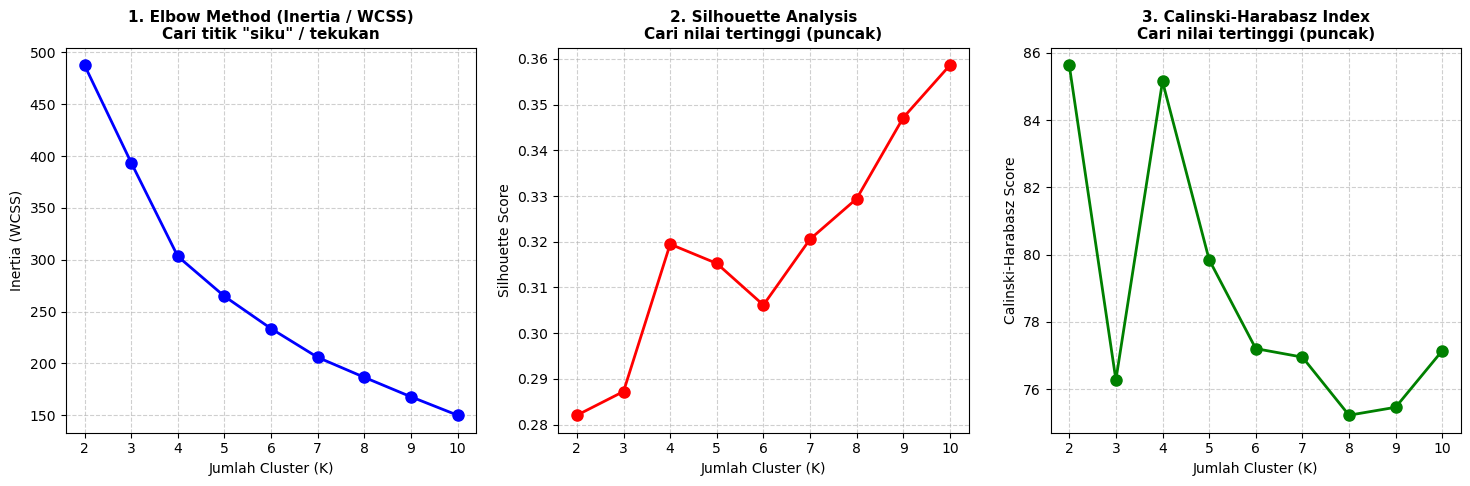

In [96]:
k_range = range(2, 11)
inertia_scores = []
silhouette_scores = []
calinski_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = kmeans.fit_predict(X_processed)
    
    inertia_scores.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_processed, labels))
    calinski_scores.append(calinski_harabasz_score(X_processed, labels))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(k_range, inertia_scores, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('1. Elbow Method (Inertia / WCSS)\nCari titik "siku" / tekukan', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Jumlah Cluster (K)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].plot(k_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_title('2. Silhouette Analysis\nCari nilai tertinggi (puncak)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Jumlah Cluster (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, linestyle='--', alpha=0.6)

axes[2].plot(k_range, calinski_scores, 'go-', linewidth=2, markersize=8)
axes[2].set_title('3. Calinski-Harabasz Index\nCari nilai tertinggi (puncak)', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Jumlah Cluster (K)')
axes[2].set_ylabel('Calinski-Harabasz Score')
axes[2].grid(True, linestyle='--', alpha=0.6)


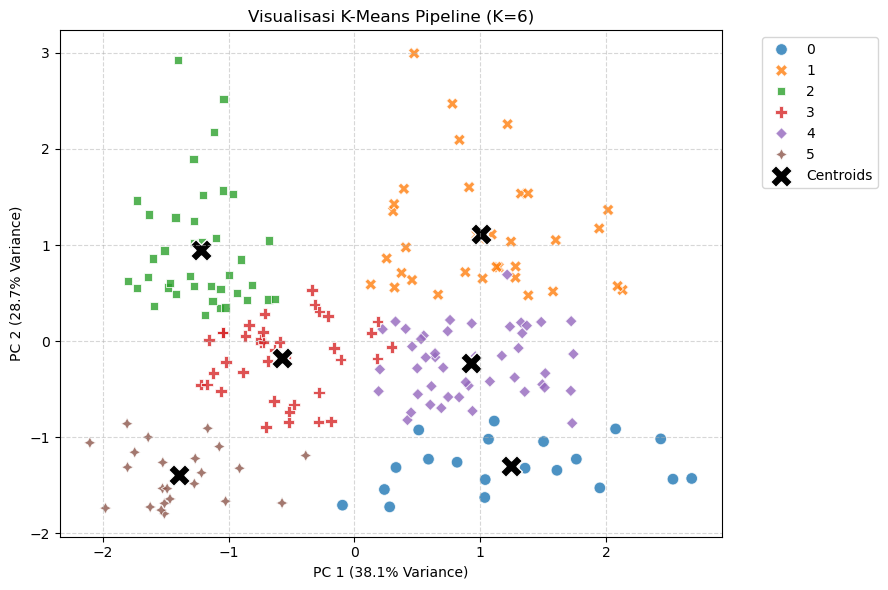

In [97]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_processed)
centroids_pca = pca.transform(best_pipeline.named_steps['clusterer'].cluster_centers_)

plt.figure(figsize=(9, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters, palette='tab10', style=clusters, s=70, alpha=0.8)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],  c='black', marker='X', s=250, label='Centroids', edgecolor='white')
plt.title(f"Visualisasi K-Means Pipeline (K={clusstering_model.best_params_['clusterer__n_clusters']})")
plt.xlabel(f"PC 1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)")
plt.ylabel(f"PC 2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [98]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,Male,19,15,39,5
1,Male,21,15,81,5
2,Female,20,16,6,0
3,Female,23,16,77,5
4,Female,31,17,40,0
